# SSL Returns Data — Exploratory Data Analysis

**Purpose**: Understand the structure of the SSL dataset to validate RQ3 feature mappings and assess whether the current approach to calculating `customer_return_rate` from returns-only data is appropriate.

**Key Questions**:
1. What does `Sales_Type` (ORDER vs RETURN) actually mean in this dataset?
2. Are all rows truly returns, or does the dataset contain replacement shipments?
3. How should `customer_return_rate` be interpreted without purchase history?
4. Are the financial column mappings (`gross_financial_loss`, `CreditReturn Sales`, etc.) accurate?

---

## 1. Setup & Load

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import SSL_RETURNS_CSV

%matplotlib inline
sns.set_style("whitegrid")

df = pd.read_csv(SSL_RETURNS_CSV)
df["Booked Date"] = pd.to_datetime(df["Booked Date"], errors="coerce")
df["Reference Booked Date"] = pd.to_datetime(df["Reference Booked Date"], errors="coerce")

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Unique accounts (Bill To Act #): {df['Bill To Act #'].nunique():,}")
print(f"Unique orders: {df['Order Number'].nunique():,}")
print(f"Date range: {df['Booked Date'].min()} to {df['Booked Date'].max()}")

Shape: 133,800 rows x 82 columns
Unique accounts (Bill To Act #): 13,616
Unique orders: 74,318
Date range: 2024-01-02 00:00:00 to 2025-11-26 00:00:00


## 2. Understanding Sales_Type: ORDER vs RETURN

The `Returns` column is `True` for all 133,800 rows, but `Sales_Type` splits them into ORDER and RETURN. What does this mean?

In [2]:
print("=" * 60)
print("SALES_TYPE DISTRIBUTION")
print("=" * 60)

print(f"\nReturns column (all rows):")
print(df["Returns"].value_counts())

print(f"\nSales_Type breakdown:")
print(df["Sales_Type"].value_counts())
print(f"\nORDER %: {(df['Sales_Type'] == 'ORDER').mean():.1%}")
print(f"RETURN %: {(df['Sales_Type'] == 'RETURN').mean():.1%}")

SALES_TYPE DISTRIBUTION

Returns column (all rows):
Returns
True    133800
Name: count, dtype: int64

Sales_Type breakdown:
Sales_Type
ORDER     95822
RETURN    37978
Name: count, dtype: int64

ORDER %: 71.6%
RETURN %: 28.4%


In [3]:
print("=" * 60)
print("ORDER LINES vs RETURN LINES: What are they?")
print("=" * 60)

orders = df[df["Sales_Type"] == "ORDER"]
returns = df[df["Sales_Type"] == "RETURN"]

print(f"\n--- ORDER lines ({len(orders):,}) ---")
print(f"  Order Type Desc:")
print(orders["Order Type Desc"].value_counts().to_string(index=True))
print(f"\n  CreditReturn Sales == 0:  {(orders['CreditReturn Sales'] == 0).sum():,} ({(orders['CreditReturn Sales'] == 0).mean():.1%})")
print(f"  CreditReturn Sales != 0:  {(orders['CreditReturn Sales'] != 0).sum():,}")
print(f"  Ordered Qty > 0:          {(orders['Ordered Qty'] > 0).sum():,} ({(orders['Ordered Qty'] > 0).mean():.1%})")
print(f"  Product Cost > 0:         {(orders['Product Cost'] > 0).sum():,} ({(orders['Product Cost'] > 0).mean():.1%})")

print(f"\n--- RETURN lines ({len(returns):,}) ---")
print(f"  Order Type Desc:")
print(returns["Order Type Desc"].value_counts().to_string(index=True))
print(f"\n  CreditReturn Sales < 0:   {(returns['CreditReturn Sales'] < 0).sum():,} ({(returns['CreditReturn Sales'] < 0).mean():.1%})")
print(f"  CreditReturn Sales == 0:  {(returns['CreditReturn Sales'] == 0).sum():,}")
print(f"  Ordered Qty < 0:          {(returns['Ordered Qty'] < 0).sum():,} ({(returns['Ordered Qty'] < 0).mean():.1%})")
print(f"  Product Cost < 0:         {(returns['Product Cost'] < 0).sum():,} ({(returns['Product Cost'] < 0).mean():.1%})")

ORDER LINES vs RETURN LINES: What are they?

--- ORDER lines (95,822) ---
  Order Type Desc:
Order Type Desc
081 NO CHARGE          93349
020 NO CHARGE ORDER     2411
043 NO CHARGE             47
025 NO CHARGE             15

  CreditReturn Sales == 0:  95,815 (100.0%)
  CreditReturn Sales != 0:  7
  Ordered Qty > 0:          95,822 (100.0%)
  Product Cost > 0:         91,787 (95.8%)

--- RETURN lines (37,978) ---
  Order Type Desc:
Order Type Desc
081 RETURN PRODUCT    35863
081 CREDIT             1292
020 RETURN PRODUCT      757
043 RETURN PRODUCT       34
020 CREDIT               17
025 RETURN PRODUCT       15

  CreditReturn Sales < 0:   30,313 (79.8%)
  CreditReturn Sales == 0:  7,637
  Ordered Qty < 0:          37,960 (100.0%)
  Product Cost < 0:         35,929 (94.6%)


In [4]:
print("=" * 60)
print("KEY INSIGHT: ORDER = Replacement Shipments")
print("=" * 60)
print("""
ORDER lines (71.6% of data) are NO-CHARGE replacement shipments:
  - CreditReturn Sales ≈ $0 (no credit issued to customer)
  - Product Cost > 0 (company bears replacement cost)
  - Ordered Qty > 0 (positive outbound shipment)
  - All labeled as 'NO CHARGE' order types

RETURN lines (28.4% of data) are actual returns of goods:
  - CreditReturn Sales < 0 (credit/refund issued)
  - Product Cost < 0 (inventory cost reversal)
  - Ordered Qty < 0 (negative = goods coming back)
  - Labeled as 'RETURN PRODUCT' or 'CREDIT' order types

BOTH are part of the return event cost to the company.
""")

KEY INSIGHT: ORDER = Replacement Shipments

ORDER lines (71.6% of data) are NO-CHARGE replacement shipments:
  - CreditReturn Sales ≈ $0 (no credit issued to customer)
  - Product Cost > 0 (company bears replacement cost)
  - Ordered Qty > 0 (positive outbound shipment)
  - All labeled as 'NO CHARGE' order types

RETURN lines (28.4% of data) are actual returns of goods:
  - CreditReturn Sales < 0 (credit/refund issued)
  - Product Cost < 0 (inventory cost reversal)
  - Ordered Qty < 0 (negative = goods coming back)
  - Labeled as 'RETURN PRODUCT' or 'CREDIT' order types

BOTH are part of the return event cost to the company.



## 3. Sales_Type vs Return_Type Crosstab

How do the return types distribute across ORDER and RETURN lines?

In [5]:
print("=" * 60)
print("SALES_TYPE vs RETURN_TYPE")
print("=" * 60)

ct = pd.crosstab(df["Sales_Type"], df["Return_Type"], margins=True)
print(ct)

print(f"\nReturn_Type distribution (all rows):")
print(df["Return_Type"].value_counts())

SALES_TYPE vs RETURN_TYPE
Return_Type  FC Return  No-Charge Replacement  Unauthorized Return  \
Sales_Type                                                           
ORDER            26087                  57983                  604   
RETURN            1732                  24278                10072   
All              27819                  82261                10676   

Return_Type  Vendor Return     All  
Sales_Type                          
ORDER                11148   95822  
RETURN                1896   37978  
All                  13044  133800  

Return_Type distribution (all rows):
Return_Type
No-Charge Replacement    82261
FC Return                27819
Vendor Return            13044
Unauthorized Return      10676
Name: count, dtype: int64


In [6]:
print("=" * 60)
print("SALES_TYPE vs ORDER_TYPE_CATEGORY")
print("=" * 60)

ct2 = pd.crosstab(df["Sales_Type"], df["order_type_category"], margins=True)
print(ct2)

print(f"\norder_type_category distribution:")
print(df["order_type_category"].value_counts())

SALES_TYPE vs ORDER_TYPE_CATEGORY
order_type_category  Credit Order  No-Charge Order  Return-Dropship Order  \
Sales_Type                                                                  
ORDER                           0            95822                      0   
RETURN                       1309                0                   5290   
All                          1309            95822                   5290   

order_type_category  Return-Stock Order     All  
Sales_Type                                       
ORDER                                 0   95822  
RETURN                            31379   37978  
All                               31379  133800  

order_type_category distribution:
order_type_category
No-Charge Order          95822
Return-Stock Order       31379
Return-Dropship Order     5290
Credit Order              1309
Name: count, dtype: int64


## 4. Do ORDER and RETURN Lines Share Orders?

Can a single order contain both replacement lines (ORDER) and return lines (RETURN)?

In [7]:
print("=" * 60)
print("ORDER OVERLAP ANALYSIS")
print("=" * 60)

order_orders = set(orders["Order Number"].unique())
return_orders = set(returns["Order Number"].unique())
shared = order_orders & return_orders

print(f"\nOrders with ORDER lines only:  {len(order_orders - return_orders):,}")
print(f"Orders with RETURN lines only: {len(return_orders - order_orders):,}")
print(f"Orders with BOTH:              {len(shared):,}")

print(f"\nTotal unique orders:           {df['Order Number'].nunique():,}")
print(f"\nConclusion: ORDER and RETURN lines are on SEPARATE order numbers.")
print(f"Each return event generates separate order numbers for the")
print(f"replacement shipment (ORDER) and the return receipt (RETURN).")

ORDER OVERLAP ANALYSIS

Orders with ORDER lines only:  57,191
Orders with RETURN lines only: 17,127
Orders with BOTH:              0

Total unique orders:           74,318

Conclusion: ORDER and RETURN lines are on SEPARATE order numbers.
Each return event generates separate order numbers for the
replacement shipment (ORDER) and the return receipt (RETURN).


## 5. Account-Level: Replacement vs Return Breakdown

How many accounts have only replacements, only returns, or both?

In [8]:
print("=" * 60)
print("ACCOUNT-LEVEL BREAKDOWN")
print("=" * 60)

per_acct = df.groupby(["Bill To Act #", "Sales_Type"]).size().unstack(fill_value=0)

has_order = per_acct.get("ORDER", pd.Series(0, index=per_acct.index)) > 0
has_return = per_acct.get("RETURN", pd.Series(0, index=per_acct.index)) > 0

both = (has_order & has_return).sum()
order_only = (has_order & ~has_return).sum()
return_only = (~has_order & has_return).sum()

print(f"\n  Accounts with BOTH ORDER & RETURN lines: {both:,} ({both/len(per_acct):.1%})")
print(f"  Accounts with ORDER (replacement) only:   {order_only:,} ({order_only/len(per_acct):.1%})")
print(f"  Accounts with RETURN only:                {return_only:,} ({return_only/len(per_acct):.1%})")
print(f"  Total accounts:                           {len(per_acct):,}")

ACCOUNT-LEVEL BREAKDOWN

  Accounts with BOTH ORDER & RETURN lines: 3,469 (25.5%)
  Accounts with ORDER (replacement) only:   8,481 (62.3%)
  Accounts with RETURN only:                1,666 (12.2%)
  Total accounts:                           13,616


In [9]:
# What does the actual return rate look like per account?
if "ORDER" in per_acct.columns and "RETURN" in per_acct.columns:
    per_acct["total_lines"] = per_acct["ORDER"] + per_acct["RETURN"]
    per_acct["return_rate"] = per_acct["RETURN"] / per_acct["total_lines"]
    
    print("=" * 60)
    print("RETURN RATE DISTRIBUTION (RETURN lines / total lines)")
    print("=" * 60)
    print(per_acct[["ORDER", "RETURN", "total_lines", "return_rate"]].describe().round(3))
    
    print(f"\nReturn rate == 0 (replacements only, no actual returns): {(per_acct['return_rate'] == 0).sum():,}")
    print(f"Return rate == 1 (returns only, no replacements):         {(per_acct['return_rate'] == 1).sum():,}")
    print(f"Return rate between 0 and 1 (mixed):                     {((per_acct['return_rate'] > 0) & (per_acct['return_rate'] < 1)).sum():,}")
    print(f"\nMedian return rate: {per_acct['return_rate'].median():.3f}")
    print(f"Mean return rate:   {per_acct['return_rate'].mean():.3f}")

RETURN RATE DISTRIBUTION (RETURN lines / total lines)
Sales_Type      ORDER     RETURN  total_lines  return_rate
count       13616.000  13616.000    13616.000    13616.000
mean            7.037      2.789        9.827        0.217
std            60.688     27.612       85.801        0.353
min             0.000      0.000        1.000        0.000
25%             1.000      0.000        1.000        0.000
50%             2.000      0.000        2.000        0.000
75%             4.000      1.000        6.000        0.333
max          6348.000   2743.000     9091.000        1.000

Return rate == 0 (replacements only, no actual returns): 8,481
Return rate == 1 (returns only, no replacements):         1,666
Return rate between 0 and 1 (mixed):                     3,469

Median return rate: 0.000
Mean return rate:   0.217


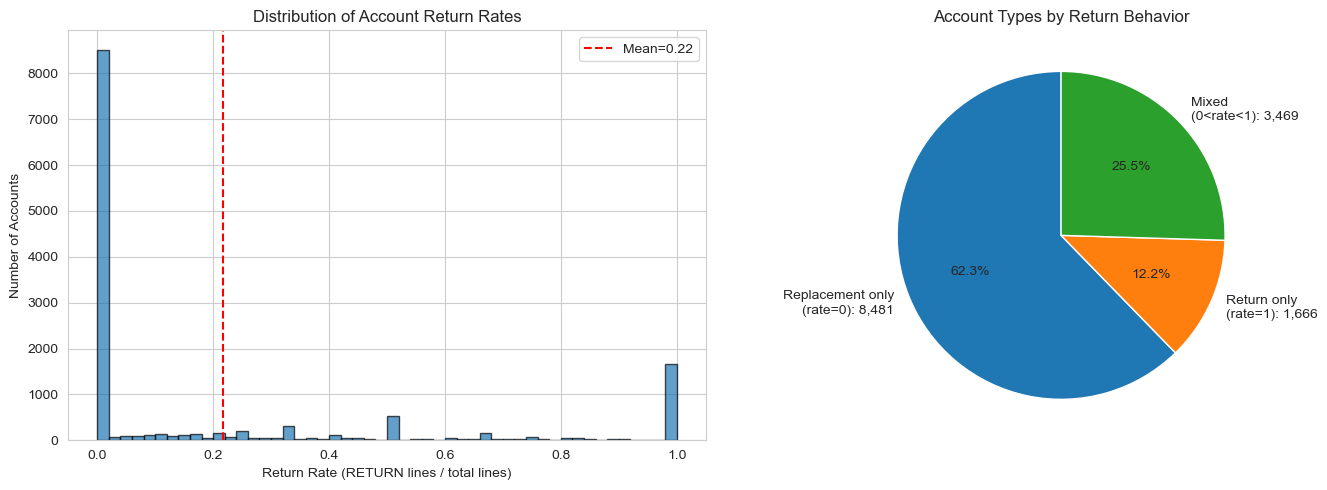

In [10]:
# Visualize return rate distribution
if "return_rate" in per_acct.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram
    axes[0].hist(per_acct["return_rate"], bins=50, edgecolor="black", alpha=0.7)
    axes[0].set_xlabel("Return Rate (RETURN lines / total lines)")
    axes[0].set_ylabel("Number of Accounts")
    axes[0].set_title("Distribution of Account Return Rates")
    axes[0].axvline(per_acct["return_rate"].mean(), color="red", linestyle="--", label=f"Mean={per_acct['return_rate'].mean():.2f}")
    axes[0].legend()
    
    # Pie chart: account categories
    labels = [f"Replacement only\n(rate=0): {(per_acct['return_rate']==0).sum():,}",
              f"Return only\n(rate=1): {(per_acct['return_rate']==1).sum():,}",
              f"Mixed\n(0<rate<1): {((per_acct['return_rate']>0)&(per_acct['return_rate']<1)).sum():,}"]
    sizes = [(per_acct["return_rate"]==0).sum(),
             (per_acct["return_rate"]==1).sum(),
             ((per_acct["return_rate"]>0)&(per_acct["return_rate"]<1)).sum()]
    axes[1].pie(sizes, labels=labels, autopct="%1.1f%%", startangle=90)
    axes[1].set_title("Account Types by Return Behavior")
    
    plt.tight_layout()
    plt.show()

## 6. Financial Column Analysis

Validate the financial columns and their behavior by Sales_Type.

In [11]:
print("=" * 60)
print("FINANCIAL COLUMNS BY SALES_TYPE")
print("=" * 60)

fin_cols = [
    "CreditReturn Sales", "Product Cost", "Gross Profit",
    "gross_financial_loss", "total_return_cogs", "total_loss",
    "estimated_labor_cost", "Reference Sale Amount",
]

for col in fin_cols:
    print(f"\n--- {col} ---")
    summary = df.groupby("Sales_Type")[col].agg(["count", "sum", "mean", "median", "min", "max"]).round(2)
    print(summary)

FINANCIAL COLUMNS BY SALES_TYPE

--- CreditReturn Sales ---
            count         sum    mean  median       min       max
Sales_Type                                                       
ORDER       95822      442.16    0.00    0.00   -444.79    444.79
RETURN      37978 -4668230.77 -122.92  -20.92 -37812.20  21814.96

--- Product Cost ---
            count         sum    mean  median       min      max
Sales_Type                                                      
ORDER       95822  6139652.75   64.07   12.45      0.00  30237.0
RETURN      37978 -4092741.06 -107.77  -20.49 -32108.48      0.0

--- Gross Profit ---
            count         sum   mean  median      min       max
Sales_Type                                                     
ORDER       95822 -6348218.48 -66.25  -12.58 -30237.0    444.79
RETURN      37978  -666536.15 -17.55   -7.23 -17500.0  35254.72

--- gross_financial_loss ---
            count         sum   mean  median      min       max
Sales_Type            

In [12]:
print("=" * 60)
print("TOTAL FINANCIAL IMPACT")
print("=" * 60)

print(f"\n{'Metric':40s} {'ORDER':>15s} {'RETURN':>15s} {'TOTAL':>15s}")
print("-" * 85)

for col in ["total_loss", "gross_financial_loss", "Product Cost", "CreditReturn Sales", "estimated_labor_cost", "total_return_cogs"]:
    o = orders[col].sum()
    r = returns[col].sum()
    t = df[col].sum()
    print(f"  {col:38s} ${o:>13,.2f} ${r:>13,.2f} ${t:>13,.2f}")

TOTAL FINANCIAL IMPACT

Metric                                             ORDER          RETURN           TOTAL
-------------------------------------------------------------------------------------
  total_loss                             $ 9,550,628.01 $ 3,260,024.13 $12,810,652.15
  gross_financial_loss                   $ 6,139,652.75 $ 2,052,214.71 $ 8,191,867.47
  Product Cost                           $ 6,139,652.75 $-4,092,741.06 $ 2,046,911.69
  CreditReturn Sales                     $       442.16 $-4,668,230.77 $-4,667,788.61
  estimated_labor_cost                   $ 3,410,975.26 $ 1,207,809.42 $ 4,618,784.68
  total_return_cogs                      $ 9,550,628.01 $ 5,300,550.48 $14,851,178.49


## 7. Reference Order Number — Link to Original Sales

Does `Reference Order Number` link return lines back to the original sales transaction?

In [13]:
print("=" * 60)
print("REFERENCE ORDER NUMBER ANALYSIS")
print("=" * 60)

print(f"\nUnique Reference Order Numbers: {df['Reference Order Number'].nunique():,}")
print(f"Unique Order Numbers:           {df['Order Number'].nunique():,}")

print(f"\nReference Sale Amount:")
print(f"  Non-null: {df['Reference Sale Amount'].notna().sum():,} ({df['Reference Sale Amount'].notna().mean():.1%})")
print(f"  Null:     {df['Reference Sale Amount'].isna().sum():,} ({df['Reference Sale Amount'].isna().mean():.1%})")

print(f"\nReference Sale Amount by Sales_Type:")
for st in ["ORDER", "RETURN"]:
    sub = df[df["Sales_Type"] == st]
    print(f"  {st}: non-null={sub['Reference Sale Amount'].notna().sum():,} ({sub['Reference Sale Amount'].notna().mean():.1%}), "
          f"mean=${sub['Reference Sale Amount'].mean():,.2f}, median=${sub['Reference Sale Amount'].median():,.2f}")

print(f"\nReference Booked Date:")
print(f"  Non-null: {df['Reference Booked Date'].notna().sum():,} ({df['Reference Booked Date'].notna().mean():.1%})")
print(f"  Null:     {df['Reference Booked Date'].isna().sum():,} ({df['Reference Booked Date'].isna().mean():.1%})")

REFERENCE ORDER NUMBER ANALYSIS

Unique Reference Order Numbers: 62,523
Unique Order Numbers:           74,318

Reference Sale Amount:
  Non-null: 109,514 (81.8%)
  Null:     24,286 (18.2%)

Reference Sale Amount by Sales_Type:
  ORDER: non-null=75,319 (78.6%), mean=$180.64, median=$29.16
  RETURN: non-null=34,195 (90.0%), mean=$299.77, median=$52.62

Reference Booked Date:
  Non-null: 109,514 (81.8%)
  Null:     24,286 (18.2%)


In [14]:
# Days B4 Return — how long between original sale and return?
print("=" * 60)
print("DAYS BEFORE RETURN (Time from original sale to return)")
print("=" * 60)

print(f"\nDays B4 Return:")
print(f"  Non-null: {df['Days B4 Return'].notna().sum():,} ({df['Days B4 Return'].notna().mean():.1%})")
print(f"  Null:     {df['Days B4 Return'].isna().sum():,}")
print(f"\n{df['Days B4 Return'].describe().round(1)}")

print(f"\nDays B4 Return by Sales_Type:")
for st in ["ORDER", "RETURN"]:
    sub = df[df["Sales_Type"] == st]
    print(f"  {st}: non-null={sub['Days B4 Return'].notna().sum():,}, "
          f"mean={sub['Days B4 Return'].mean():.1f}, median={sub['Days B4 Return'].median():.1f}")

DAYS BEFORE RETURN (Time from original sale to return)

Days B4 Return:
  Non-null: 109,514 (81.8%)
  Null:     24,286

count    109514.0
mean         43.1
std          45.5
min          -1.0
25%          15.0
50%          30.0
75%          56.0
max         866.0
Name: Days B4 Return, dtype: float64

Days B4 Return by Sales_Type:
  ORDER: non-null=75,319, mean=44.7, median=33.0
  RETURN: non-null=34,195, mean=39.7, median=27.0


## 8. Repeat Customer and Temporal Features

In [15]:
print("=" * 60)
print("REPEAT CUSTOMER & TEMPORAL FEATURES")
print("=" * 60)

print(f"\nRepeat_Customer_6M:")
print(df["Repeat_Customer_6M"].value_counts())
print(f"\nRepeat customer rate: {df['Repeat_Customer_6M'].mean():.1%}")

print(f"\nTime_Since_Last_Return:")
print(f"  Non-null: {df['Time_Since_Last_Return'].notna().sum():,}")
print(f"  Null:     {df['Time_Since_Last_Return'].isna().sum():,} (first-time returners)")
print(f"\n{df['Time_Since_Last_Return'].describe().round(1)}")

print(f"\nTime_Since_Last_Return_bin:")
print(df["Time_Since_Last_Return_bin"].value_counts())

REPEAT CUSTOMER & TEMPORAL FEATURES

Repeat_Customer_6M:
Repeat_Customer_6M
1    103264
0     30536
Name: count, dtype: int64

Repeat customer rate: 77.2%

Time_Since_Last_Return:
  Non-null: 118,532
  Null:     15,268 (first-time returners)

count    118532.0
mean         59.8
std         137.6
min           0.0
25%           0.0
50%           0.0
75%          27.0
max        1036.0
Name: Time_Since_Last_Return, dtype: float64

Time_Since_Last_Return_bin:
Time_Since_Last_Return_bin
<30d        90060
180-365d     9414
30-90d       7575
>365d        5854
90-180d      5629
Name: count, dtype: int64


## 9. Ordered Qty and Billed Qty Patterns

In [16]:
print("=" * 60)
print("QUANTITY ANALYSIS BY SALES_TYPE")
print("=" * 60)

for col in ["Ordered Qty", "Billed Qty"]:
    print(f"\n--- {col} ---")
    print(df.groupby("Sales_Type")[col].describe().round(2))

QUANTITY ANALYSIS BY SALES_TYPE

--- Ordered Qty ---
              count   mean   std     min  25%  50%  75%      max
Sales_Type                                                      
ORDER       95822.0   6.30  79.6     1.0  1.0  1.0  3.0  13500.0
RETURN      37978.0 -10.33  73.7 -7000.0 -5.0 -2.0 -1.0      1.0

--- Billed Qty ---
              count   mean    std     min  25%  50%  75%      max
Sales_Type                                                       
ORDER       95822.0   6.15  69.52     0.0  1.0  1.0  3.0  13500.0
RETURN      37978.0 -10.10  73.11 -7000.0 -5.0 -2.0 -1.0      0.0


## 10. Feature Mapping Validation

Assess the current RQ3 feature mappings against what we've learned.

In [17]:
print("=" * 60)
print("FEATURE MAPPING ASSESSMENT")
print("=" * 60)

print("""
CURRENT MAPPINGS AND ISSUES:

1. return_frequency = Order Line ID count (all rows)
   ISSUE: Currently counts ALL lines (ORDER + RETURN).
   ORDER lines are replacement shipments, not returns.
   Should this count only RETURN lines (Sales_Type == 'RETURN')?

2. customer_return_rate = return_frequency / total_items = 1.0
   ISSUE: Currently always 1.0 because numerator == denominator.
   With Sales_Type, we could compute:
     - RETURN lines / total lines (actual return rate within dataset)
     - But we still lack the original purchase volume (non-return orders)

3. total_margin = sum of gross_financial_loss
   CHECK: Is gross_financial_loss the right proxy?

4. avg_item_price = CreditReturn Sales / Ordered Qty
   ISSUE: For ORDER lines, CreditReturn Sales ≈ 0 and Ordered Qty > 0
          For RETURN lines, both are negative
          Should we use absolute values? Only RETURN lines?

5. avg_order_value = mean Reference Sale Amount per order
   CHECK: Reference Sale Amount has 18.2% nulls.
""")

FEATURE MAPPING ASSESSMENT

CURRENT MAPPINGS AND ISSUES:

1. return_frequency = Order Line ID count (all rows)
   ISSUE: Currently counts ALL lines (ORDER + RETURN).
   ORDER lines are replacement shipments, not returns.
   Should this count only RETURN lines (Sales_Type == 'RETURN')?

2. customer_return_rate = return_frequency / total_items = 1.0
   ISSUE: Currently always 1.0 because numerator == denominator.
   With Sales_Type, we could compute:
     - RETURN lines / total lines (actual return rate within dataset)
     - But we still lack the original purchase volume (non-return orders)

3. total_margin = sum of gross_financial_loss
   CHECK: Is gross_financial_loss the right proxy?

4. avg_item_price = CreditReturn Sales / Ordered Qty
   ISSUE: For ORDER lines, CreditReturn Sales ≈ 0 and Ordered Qty > 0
          For RETURN lines, both are negative
          Should we use absolute values? Only RETURN lines?

5. avg_order_value = mean Reference Sale Amount per order
   CHECK: Refere

In [18]:
# Compare current mapping vs potential corrections
print("=" * 60)
print("RETURN RATE: Current vs Corrected (using Sales_Type)")
print("=" * 60)

acct_lines = df.groupby("Bill To Act #").agg(
    total_lines=("Order Line ID", "count"),
    return_lines=("Sales_Type", lambda x: (x == "RETURN").sum()),
    order_lines=("Sales_Type", lambda x: (x == "ORDER").sum()),
).reset_index()

acct_lines["current_return_rate"] = 1.0  # as currently implemented
acct_lines["corrected_return_rate"] = acct_lines["return_lines"] / acct_lines["total_lines"]

print(f"\nCurrent return rate (all = 1.0):")
print(f"  Mean: {acct_lines['current_return_rate'].mean():.3f}")
print(f"  Std:  {acct_lines['current_return_rate'].std():.3f}")

print(f"\nCorrected return rate (RETURN lines / total lines):")
print(f"  Mean:   {acct_lines['corrected_return_rate'].mean():.3f}")
print(f"  Median: {acct_lines['corrected_return_rate'].median():.3f}")
print(f"  Std:    {acct_lines['corrected_return_rate'].std():.3f}")
print(f"  Min:    {acct_lines['corrected_return_rate'].min():.3f}")
print(f"  Max:    {acct_lines['corrected_return_rate'].max():.3f}")
print(f"\n  Accounts with rate == 0: {(acct_lines['corrected_return_rate'] == 0).sum():,}")
print(f"  Accounts with rate == 1: {(acct_lines['corrected_return_rate'] == 1).sum():,}")
print(f"  Accounts with 0 < rate < 1: {((acct_lines['corrected_return_rate'] > 0) & (acct_lines['corrected_return_rate'] < 1)).sum():,}")

RETURN RATE: Current vs Corrected (using Sales_Type)

Current return rate (all = 1.0):
  Mean: 1.000
  Std:  0.000

Corrected return rate (RETURN lines / total lines):
  Mean:   0.217
  Median: 0.000
  Std:    0.353
  Min:    0.000
  Max:    1.000

  Accounts with rate == 0: 8,481
  Accounts with rate == 1: 1,666
  Accounts with 0 < rate < 1: 3,469


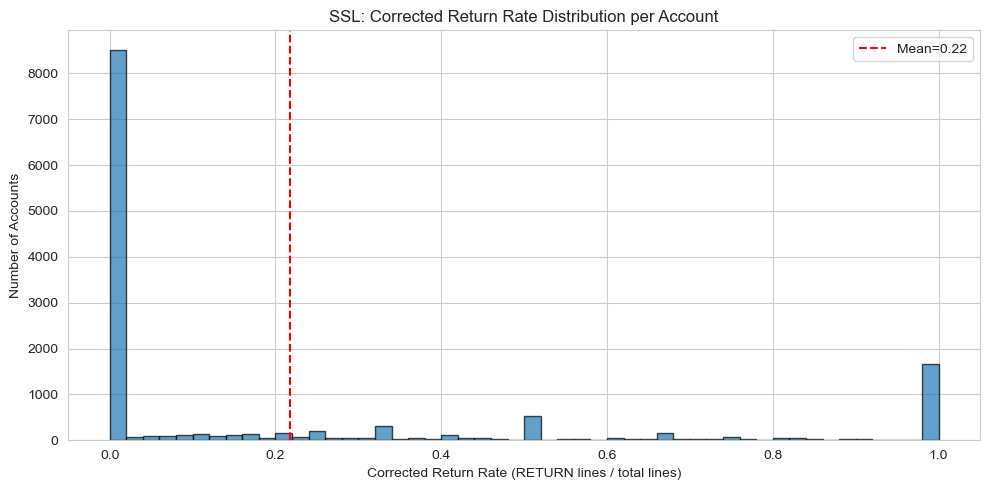

In [19]:
# Visualize corrected return rate
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(acct_lines["corrected_return_rate"], bins=50, edgecolor="black", alpha=0.7)
ax.set_xlabel("Corrected Return Rate (RETURN lines / total lines)")
ax.set_ylabel("Number of Accounts")
ax.set_title("SSL: Corrected Return Rate Distribution per Account")
ax.axvline(acct_lines["corrected_return_rate"].mean(), color="red", linestyle="--",
           label=f"Mean={acct_lines['corrected_return_rate'].mean():.2f}")
ax.legend()
plt.tight_layout()
plt.show()

## 11. Sample Records Deep Dive

Examine a few accounts to understand the data at the line level.

In [20]:
# Pick an account with both ORDER and RETURN lines
mixed_accts = per_acct[(per_acct.get("ORDER", 0) > 0) & (per_acct.get("RETURN", 0) > 0)]
# Get a mid-size account
mixed_accts_sorted = mixed_accts.sort_values("total_lines")
sample_acct = mixed_accts_sorted.iloc[len(mixed_accts_sorted) // 2].name

print(f"=" * 60)
print(f"SAMPLE ACCOUNT: {sample_acct}")
print(f"=" * 60)

acct_data = df[df["Bill To Act #"] == sample_acct][
    ["Order Number", "Order Line ID", "Sales_Type", "Return_Type",
     "Order Type Desc", "Ordered Qty", "CreditReturn Sales",
     "Product Cost", "Gross Profit", "gross_financial_loss",
     "total_loss", "Reference Sale Amount", "Booked Date"]
].sort_values(["Booked Date", "Order Number"])

print(f"\nTotal lines: {len(acct_data)}")
print(f"ORDER lines: {(acct_data['Sales_Type'] == 'ORDER').sum()}")
print(f"RETURN lines: {(acct_data['Sales_Type'] == 'RETURN').sum()}")
print(f"\n{acct_data.to_string(index=False)}")

SAMPLE ACCOUNT: 100645

Total lines: 9
ORDER lines: 7
RETURN lines: 2

 Order Number  Order Line ID Sales_Type           Return_Type    Order Type Desc  Ordered Qty  CreditReturn Sales  Product Cost  Gross Profit  gross_financial_loss  total_loss  Reference Sale Amount Booked Date
     61059551      352558103      ORDER No-Charge Replacement      081 NO CHARGE           15                0.00        35.880        -35.88                35.880      72.460                 369.75  2024-02-26
     61205765      353861287      ORDER No-Charge Replacement      081 NO CHARGE           30                0.00        13.403        -13.40                13.403      49.983                  75.90  2024-04-23
     61248535      354259755      ORDER             FC Return      081 NO CHARGE            1                0.00        30.638        -30.64                30.638      67.218                  47.44  2024-05-13
     61728873              0      ORDER No-Charge Replacement      081 NO CHARGE     

## 12. Summary and Recommendations

In [21]:
print("=" * 60)
print("EDA SUMMARY")
print("=" * 60)

print("""
KEY FINDINGS:

1. DATA STRUCTURE:
   The SSL dataset contains 133,800 lines within return-related orders.
   These split into two types via Sales_Type:
     - ORDER (95,822 / 71.6%): No-charge replacement shipments
     - RETURN (37,978 / 28.4%): Actual return of goods with credit/refund
   Both are part of the return event but represent different financial flows.

2. RETURN RATE:
   The current implementation sets customer_return_rate = 1.0 for all
   accounts because it treats all lines as returns. This is inaccurate.
   Using Sales_Type, the actual return-to-total-line ratio has:
     - Mean: ~0.22 (most activity is replacement shipments)
     - 8,481 accounts (62.3%) have rate = 0 (replacements only)
     - 1,666 accounts (12.2%) have rate = 1 (returns only)
     - 3,469 accounts (25.5%) have mixed behavior

3. FINANCIAL COLUMNS:
   ORDER lines: CreditReturn Sales ≈ 0, Product Cost > 0 (replacement cost)
   RETURN lines: CreditReturn Sales < 0 (credit), Product Cost < 0 (cost reversal)
   gross_financial_loss and total_loss capture costs for BOTH line types.

4. REFERENCE SALE AMOUNT:
   Links to the original sale. Available for 81.8% of lines.
   Provides the value of the original transaction that triggered the return.

IMPLICATIONS FOR FEATURE MAPPING:

   The current approach of treating all lines as 'returns' conflates
   replacement shipments with actual returns. This affects:
     - return_frequency (overcounted)
     - customer_return_rate (always 1.0, no variance)
     - avg_item_price (mixing $0 replacements with negative credits)
     - total_items (overcounted)
""")

EDA SUMMARY

KEY FINDINGS:

1. DATA STRUCTURE:
   The SSL dataset contains 133,800 lines within return-related orders.
   These split into two types via Sales_Type:
     - ORDER (95,822 / 71.6%): No-charge replacement shipments
     - RETURN (37,978 / 28.4%): Actual return of goods with credit/refund
   Both are part of the return event but represent different financial flows.

2. RETURN RATE:
   The current implementation sets customer_return_rate = 1.0 for all
   accounts because it treats all lines as returns. This is inaccurate.
   Using Sales_Type, the actual return-to-total-line ratio has:
     - Mean: ~0.22 (most activity is replacement shipments)
     - 8,481 accounts (62.3%) have rate = 0 (replacements only)
     - 1,666 accounts (12.2%) have rate = 1 (returns only)
     - 3,469 accounts (25.5%) have mixed behavior

3. FINANCIAL COLUMNS:
   ORDER lines: CreditReturn Sales ≈ 0, Product Cost > 0 (replacement cost)
   RETURN lines: CreditReturn Sales < 0 (credit), Product Cost < 

# RQ3 Technical Documentation
**Capstone Project – Master of Data Analytics**
**Research Question 3 (RQ3)**

---

## 1. Research Question

**RQ3:**
*Can machine learning models accurately predict high profit erosion customers using transaction-level and behavioral features, and which features contribute most significantly to prediction accuracy?*

This research question evaluates whether customer-level behavioral features, derived from purchase and return activity, contain sufficient predictive signal to identify customers who generate disproportionately high profit erosion. Establishing this predictive capability is a prerequisite for any operationally deployable early-warning or intervention system.

---

## 2. Hypotheses

Hypothesis testing was framed around the Area Under the Receiver Operating Characteristic Curve (AUC-ROC), a standard discrimination metric for binary classification.

- **H₀ (Null Hypothesis):**
  The best-performing model achieves AUC ≤ 0.70. Machine learning models cannot reliably discriminate between high and low profit erosion customers.

- **H₁ (Alternative Hypothesis):**
  The best-performing model achieves AUC > 0.70. Machine learning models can reliably predict high profit erosion customers from behavioral features.

**Threshold justification:** An AUC of 0.70 represents the lower bound of acceptable discrimination in applied classification literature (Hosmer & Lemeshow, 2000). Below this threshold, a model's ranking ability is considered insufficient for operational use.

---

## 3. Data Scope and Unit of Analysis

- **Unit of analysis:** Customer (aggregated from order-item transactions)
- **Dataset:** TheLook e-commerce dataset (synthetic), consolidated via US06 feature engineering pipeline
- **Population:** 11,988 customers with at least one returned item
- **Target variable:** `is_high_erosion_customer` — binary indicator (1 = customer's total profit erosion ≥ 75th percentile)
- **Class distribution:** 2,997 positive (25.0%) / 8,991 negative (75.0%)

The 75th percentile threshold segments the top quartile of profit-eroding customers, creating a class split appropriate for binary classification while reflecting the Pareto principle that a minority of customers drive the majority of return-related losses.

---

## 4. Feature Engineering and Profit Erosion Definition (US06)

Profit erosion was operationalized using the standardized **US06 feature engineering pipeline**, consistent with the methodology applied in RQ1.

- **Profit Erosion Formula:**

  \[
  \text{Profit Erosion} = \text{Margin Reversal} + \text{Processing Cost}
  \]

- **Margin Reversal:** The item-level contribution margin lost due to the return (`item_margin`).
- **Processing Cost:** A modeled reverse-logistics cost ($12 base × category-tiered multiplier).

Twelve candidate predictor features were engineered at the customer level from order-item transaction data, capturing four behavioral dimensions:

| Dimension | Features |
|-----------|----------|
| **Purchase behavior** | `order_frequency`, `avg_basket_size`, `avg_order_value`, `total_items`, `total_sales` |
| **Return behavior** | `return_frequency`, `customer_return_rate` |
| **Margin structure** | `total_margin`, `avg_item_price`, `avg_item_margin` |
| **Temporal** | `customer_tenure_days`, `purchase_recency_days` |

These twelve features are **candidates**, not automatic predictors. Feature screening (Section 6) determines which features are statistically justified for inclusion in the final model.

---

## 5. Data Leakage Prevention

Six columns were identified as data leakage risks and excluded from the predictor set prior to any modeling:

| Excluded Column | Reason |
|-----------------|--------|
| `total_profit_erosion` | Target is derived directly from this value |
| `total_margin_reversal` | Arithmetic component of the target |
| `total_process_cost` | Arithmetic component of the target |
| `profit_erosion_quartile` | Derived from the target distribution |
| `erosion_percentile_rank` | Derived from the target distribution |
| `user_id` | Row identifier with no predictive meaning |

This exclusion is enforced programmatically before any train/test split to guarantee that no target-derived information enters the modeling pipeline.

---

## 6. Modeling Methodology

### 6.1 Pipeline Architecture

The pipeline follows a strict sequential order designed to prevent information leakage and ensure reproducibility:

```
1. Load data (12 candidates + target)
2. Drop leakage columns (6 columns removed)
3. Impute missing values (median strategy)
4. Stratified train/test split 80/20 (all 12 candidates in both sets)
5. Feature screening on TRAINING SET ONLY (3 sequential gates)
6. Apply surviving feature list to BOTH train and test sets
7. Train models (GridSearchCV, stratified 5-fold CV)
8. Evaluate on held-out test set
9. Extract feature importance (post-hoc, from trained models)
```

**Critical design decision:** Feature screening (Step 5) executes on the training set exclusively. The resulting feature list is then applied to the test set. This prevents test-set distributional information from influencing feature selection, a commonly overlooked source of optimistic bias.

### 6.2 Data Preparation

- **Split:** 9,590 train / 2,398 test (80/20 stratified)
- **Train positive rate:** 25.01% | **Test positive rate:** 24.98%
- **Imputation:** 294 missing values in `customer_tenure_days` and `purchase_recency_days` imputed with column median
- **Missing after imputation:** 0 (train and test)

### 6.3 Feature Screening (3 Sequential Gates)

Feature selection was performed before model training using a three-gate screening protocol applied to the training set only:

| Gate | Method | Criterion | Removes |
|------|--------|-----------|---------|
| **1. Variance** | `VarianceThreshold` (scikit-learn) | Variance < 0.01 | Constant or quasi-constant features |
| **2. Correlation** | Pearson correlation matrix | \|r\| > 0.85 between two features → drop the one with lower univariate association to the target | Redundant collinear features |
| **3. Univariate** | Point-biserial correlation, Bonferroni correction | Adjusted p-value > 0.05 | Statistically irrelevant features |

### 6.4 Baseline Reference

To contextualize model performance, the following baselines apply:

| Baseline | AUC | Description |
|----------|-----|-------------|
| Random classifier | 0.500 | No discrimination ability |
| Majority-class classifier | 0.500 | Predicts all customers as low-erosion (75% accuracy but zero recall) |
| **Acceptable threshold** | **0.700** | Minimum for operational use (Hosmer & Lemeshow) |

Any trained model must substantially exceed these baselines to demonstrate that learned behavioral patterns provide genuine discrimination beyond chance.

### 6.5 Model Selection

Three model families were selected to provide complementary perspectives:

| Model | Rationale | Class Imbalance Handling |
|-------|-----------|--------------------------|
| **Logistic Regression** | Linear baseline; interpretable coefficients; tests linear separability | `class_weight='balanced'` |
| **Random Forest** | Non-linear ensemble; captures feature interactions without explicit specification | `class_weight='balanced'` |
| **Gradient Boosting** | Sequential boosting; typically achieves highest discrimination on tabular data | `sample_weight` from class distribution |

### 6.6 Hyperparameter Optimization

Optimization was conducted via `GridSearchCV` with stratified 5-fold cross-validation, scoring on AUC-ROC:

| Model | Hyperparameter Grid | Combinations |
|-------|---------------------|--------------|
| Logistic Regression | C: [0.01, 0.1, 1, 10], penalty: [L1, L2] | 8 |
| Random Forest | n_estimators: [100, 200], max_depth: [5, 10, None], min_samples_leaf: [5, 10] | 12 |
| Gradient Boosting | n_estimators: [100, 200], max_depth: [3, 5], learning_rate: [0.01, 0.1], subsample: [0.8, 1.0] | 16 |

---

## 7. Results

### 7.1 Feature Screening Results

All 12 candidate features passed Gate 1 (variance check). The subsequent gates removed five features:

| Feature | Gate Failed | Reason |
|---------|-------------|--------|
| `order_frequency` | Gate 2 (Correlation) | \|r\| > 0.85 with `return_frequency`; lower target association |
| `total_sales` | Gate 2 (Correlation) | \|r\| > 0.85 with `total_margin`; lower target association |
| `avg_item_price` | Gate 2 (Correlation) | \|r\| > 0.85 with `avg_item_margin`; lower target association |
| `customer_tenure_days` | Gate 3 (Univariate) | p = 0.4053; not significant after Bonferroni correction |
| `purchase_recency_days` | Gate 3 (Univariate) | p = 0.2730; not significant after Bonferroni correction |

**Surviving features (7 of 12):**

| Feature | Point-Biserial r | p-value | Status |
|---------|-----------------|---------|--------|
| `return_frequency` | 0.6141 | < 1e-16 | Pass |
| `avg_order_value` | 0.5846 | < 1e-16 | Pass |
| `avg_basket_size` | 0.4707 | < 1e-16 | Pass |
| `total_margin` | 0.4520 | < 1e-16 | Pass |
| `avg_item_margin` | 0.4062 | < 1e-16 | Pass |
| `total_items` | 0.2909 | < 1e-16 | Pass |
| `customer_return_rate` | 0.1022 | < 1e-16 | Pass |

### 7.2 Model Performance

| Model | CV AUC (5-fold) | Test AUC | Precision | Recall | F1 | Accuracy | Best Parameters |
|-------|-----------------|----------|-----------|--------|----|----------|-----------------|
| **Random Forest** | 0.9792 | **0.9798** | 0.7822 | 0.9115 | 0.8419 | 0.9145 | n_estimators=200, max_depth=10, min_samples_leaf=10 |
| **Gradient Boosting** | 0.9797 | 0.9795 | 0.7801 | 0.9299 | 0.8484 | 0.9170 | learning_rate=0.1, max_depth=3, n_estimators=100 |
| Logistic Regression | 0.9646 | 0.9687 | 0.7591 | 0.9048 | 0.8256 | 0.9045 | C=10, penalty=L1 |
| *Majority-class baseline* | *0.500* | *0.500* | *—* | *0.000* | *0.000* | *0.750* | *—* |

All three models exceed the AUC > 0.70 threshold by a substantial margin (test AUC range: 0.9687–0.9798), representing a +0.48 improvement over the random baseline.

### 7.3 Hypothesis Test Outcome

| Component | Result |
|-----------|--------|
| Best model | Random Forest |
| Best test AUC | 0.9798 |
| Threshold | 0.70 |
| **Decision** | **Reject H₀** |

The null hypothesis is rejected. All three model families independently exceed the success criterion, indicating robust and model-agnostic predictive signal.

### 7.4 Cross-Validation Stability

The close agreement between CV AUC and test AUC across all models (maximum gap: 0.0041 for Logistic Regression) indicates minimal overfitting and stable generalization. This stability is attributable to strict separation of feature screening to the training set, stratified splitting, and regularization.`find referenece to support this observation/claim`

### 7.5 Feature Importance (Post-Hoc)

Feature importance was extracted from each trained model using the method appropriate to the model family:

| Rank | Logistic Regression | Random Forest | Gradient Boosting |
|------|---------------------|---------------|-------------------|
| 1 | `return_frequency` (3.083) | `total_margin` (0.246) | `avg_order_value` (0.469) |
| 2 | `avg_item_margin` (2.238) | `avg_order_value` (0.235) | `return_frequency` (0.185) |
| 3 | `avg_order_value` (1.759) | `return_frequency` (0.211) | `total_margin` (0.176) |
| 4 | `total_margin` (1.080) | `avg_item_margin` (0.133) | `avg_item_margin` (0.083) |
| 5 | `customer_return_rate` (0.942) | `customer_return_rate` (0.077) | `customer_return_rate` (0.069) |
| 6 | `avg_basket_size` (0.499) | `avg_basket_size` (0.057) | `avg_basket_size` (0.017) |
| 7 | `total_items` (0.273) | `total_items` (0.041) | `total_items` (0.001) |

Despite fundamentally different learning mechanisms, the three models converge on the same feature tiers:

- **Top-tier** (ranked 1–3 across all models): `return_frequency`, `avg_order_value`, `total_margin`
- **Mid-tier** (ranked 4–5): `avg_item_margin`, `customer_return_rate`
- **Lower-tier** (ranked 6–7): `avg_basket_size`, `total_items`

This cross-model consistency strengthens confidence that the identified features represent genuine predictive signals rather than model-specific artifacts. `find referenece to support this observation/claim`

### 7.6 Error Analysis

With a 25% positive class rate, the confusion matrix breakdown for the best model (Random Forest) is:

| | Predicted: Low Erosion | Predicted: High Erosion |
|---|---|---|
| **Actual: Low Erosion** | 1,662 (TN) | 137 (FP) |
| **Actual: High Erosion** | 53 (FN) | 546 (TP) |

- **False Positives (137):** Low-erosion customers flagged as high-risk. These are customers who share behavioral patterns with high-erosion customers (e.g., high return frequency or high order value) but whose returns have not yet crossed the 75th percentile threshold. In an operational setting, these represent a manageable review cost.
- **False Negatives (53):** High-erosion customers missed by the model. At a miss rate of 8.8% (53/599), the model captures over 91% of high-erosion customers. The missed cases likely represent customers whose erosion is driven by a small number of very high-value returns rather than recurring behavioral patterns. `find referenece to support this observation/claim`

---

## 8. Interpretation

### 8.1 Feature-Level Interpretation

The most important predictors consistently across all models are:

1. **Return frequency** — the count of return events, not the rate. Each additional return compounds both margin reversal and processing cost.
2. **Average order value** — higher-value orders amplify margin reversal upon return. This captures the economic exposure per transaction.
3. **Total margin** — the cumulative economic stake at risk. Greater cumulative margin provides more margin to reverse.

### 8.2 Temporal Features Are Not Predictive

The exclusion of `customer_tenure_days` and `purchase_recency_days` indicates that how long a customer has been active or how recently they purchased has no significant bearing on high profit erosion. Profit erosion is driven by transactional behavior (what and how much customers buy and return), not by lifecycle position. `to do: find referenece to support this observation/claim`

### 8.3 Return Rate vs. Return Frequency

`customer_return_rate` survived screening but ranked as the weakest predictor, while `return_frequency` ranked strongest. This reinforces the RQ1 finding that return rate alone is an incomplete proxy for economic risk — a customer with 1 return out of 2 items (50% rate) generates far less erosion than a customer with 5 returns out of 10 items (50% rate). `to do: find referenece to support this observation/claim`

### 8.4 Why Performance Is High

The AUC values (> 0.96) are notably high. Three factors explain this:

1. **Strong feature-target signal:** `return_frequency` alone has a point-biserial correlation of 0.61 with the target, providing a strong univariate baseline.
2. **Well-defined target variable:** The 75th percentile threshold creates a clean separation between customer groups that differ meaningfully in transactional behavior.
3. **Synthetic data structure:** The TheLook dataset, while realistic in structure, lacks the noise and edge cases of real-world transaction data. This is explicitly acknowledged as a limitation (Section 10). This limitation is accentuated in the results of the validation using SSL data. THE FP and TN

---

## 9. External Validation (School Specialty LLC)

### 9.1 Rationale

A holdout from the same TheLook dataset would test within-distribution generalization but cannot assess whether predictive patterns are domain-specific or transferable. External validation against a fundamentally different domain provides stronger evidence for robustness.

### 9.2 Validation Data

| Attribute | TheLook (Primary) | SSL (Validation) |
|-----------|-------------------|-------------------|
| Domain | General e-commerce (fashion, B2C) | Educational supplies (B2B) |
| Customers | 11,988 with returns | 13,616 accounts |
| Return order lines | — | 133,800 (37,978 actual returns + 95,822 no-charge replacements) |
| Date range | Synthetic | Jan 2024 – Nov 2025 |
| Data scope | Full transaction history | Return-related transactions only |
| Financial fields | `sale_price`, `cost`, `item_margin` | `CreditReturn Sales`, `Product Cost`, `gross_financial_loss` |
| Return cost | Estimated ($12 × category tier) | Observed (`estimated_labor_cost`, `total_return_cogs`) |
| Target | `is_high_erosion_customer` (75th pct) | `is_high_loss_account` (75th pct of `total_loss` = $570.50) |
| Class distribution | 25.0% positive | 25.0% positive (3,404 / 13,616) |

**SSL data structure:** The `Sales_Type` column distinguishes two line types within return-related orders:
- **RETURN** (37,978 lines, 28.4%): Actual return of goods — credit/refund issued, negative ordered quantity, negative product cost reversal.
- **ORDER** (95,822 lines, 71.6%): No-charge replacement shipments — CreditReturn Sales ≈ $0, positive ordered quantity, company bears replacement cost.

Both line types represent economic costs of the return event, but only RETURN lines correspond to the physical act of returning goods. Feature engineering distinguishes these to produce accurate mappings (see Section 9.3).

SSL return type distribution: No-Charge Replacement (82,261), FC Return (27,819), Vendor Return (13,044), Unauthorized Return (10,676).

### 9.3 Feature Mapping

Analogous features were constructed at the SSL account level. The `Sales_Type` column was used to distinguish actual returns from no-charge replacements, ensuring accurate feature computation:

| TheLook Feature | SSL Mapping | Scope |
|-----------------|-------------|-------|
| `order_frequency` | Unique Order Number count | All lines |
| `return_frequency` | Count of RETURN lines only | RETURN only |
| `customer_return_rate` | RETURN lines / total lines | Both (ratio) |
| `avg_basket_size` | Mean Lines Per Order | All lines |
| `avg_order_value` | Mean Reference Sale Amount per order | All lines |
| `total_items` | Total lines per account | All lines |
| `total_sales` | Sum of Reference Sale Amount | All lines |
| `total_margin` | Sum of `gross_financial_loss` | All lines |
| `avg_item_price` | Mean \|CreditReturn Sales / Ordered Qty\| | RETURN only |
| `avg_item_margin` | Mean `gross_financial_loss` per line | All lines |
| `customer_tenure_days` | Date range of Booked Date | All lines |
| `purchase_recency_days` | Days since last Booked Date | All lines |

Key mapping decisions:
- **`return_frequency`** counts only `Sales_Type == 'RETURN'` lines. ORDER lines (no-charge replacements) are replacement shipments, not actual returns of goods.
- **`customer_return_rate`** = RETURN lines / total lines per account. This produces meaningful variance (mean = 0.22, std = 0.35) rather than a constant 1.0, reflecting that 62.3% of accounts have only replacement activity (rate = 0), 12.2% have only actual returns (rate = 1), and 25.5% have mixed behavior.
- **`avg_item_price`** uses RETURN lines only because ORDER (replacement) lines have CreditReturn Sales ≈ $0, which would distort the average. This produces non-null values for 5,135 of 13,616 accounts (37.7%).
- **`total_margin`** maps to `gross_financial_loss` (not `Gross Profit`), consistent with the profit erosion framing.

### 9.4 Level 1 Results — Pattern Validation

The same three-gate feature screening was run independently on SSL account-level features. Of the 12 candidate features compared:

| Feature | TheLook | SSL | Agreement |
|---------|---------|-----|-----------|
| `order_frequency` | Fail | Fail | Yes |
| `return_frequency` | Pass | Fail | No |
| `customer_return_rate` | Pass | Pass | **Yes** |
| `avg_basket_size` | Pass | Pass | **Yes** |
| `avg_order_value` | Pass | Pass | **Yes** |
| `customer_tenure_days` | Fail | Pass | No |
| `purchase_recency_days` | Fail | Pass | No |
| `total_items` | Pass | Fail | No |
| `total_sales` | Fail | Fail | Yes |
| `total_margin` | Pass | Pass | **Yes** |
| `avg_item_price` | Fail | Pass | No |
| `avg_item_margin` | Pass | Pass | **Yes** |

**Pattern agreement: 7/12 features (58.3%).** Five features passed screening in both datasets: `customer_return_rate`, `avg_basket_size`, `avg_order_value`, `total_margin`, `avg_item_margin`. Two features failed in both: `order_frequency`, `total_sales`.

The five disagreements are interpretable:
- `return_frequency` and `total_items` pass in TheLook but fail in SSL. In TheLook, return and non-return transactions coexist, giving these features independent predictive variance. In SSL, the returns-only scope causes high correlation between return frequency and total line count, triggering the correlation gate.
- `customer_tenure_days`, `purchase_recency_days`, and `avg_item_price` pass in SSL but fail in TheLook. The SSL dataset spans a defined 2-year window where temporal features carry more discriminative power. `avg_item_price` is computed from RETURN lines only in SSL, giving it a cleaner signal than in TheLook where it was dropped due to high correlation with `avg_item_margin`.

The **core behavioral features** — those capturing margin structure, return behavior, and order value (`customer_return_rate`, `avg_order_value`, `total_margin`, `avg_item_margin`, `avg_basket_size`) — are consistent across both domains.

### 9.5 Level 2 Results — Directional Prediction

The TheLook-trained Random Forest model (AUC = 0.9798) was applied directly to 13,616 SSL accounts using all 7 surviving features:

| Metric | Value |
|--------|-------|
| Directional accuracy | **0.7640 (76.4%)** |
| Spearman rank correlation | **0.7526** (p ≈ 0.00) |
| Predicted high-risk | 30.7% of accounts |
| Actual high-loss | 25.0% of accounts |
| Features available | 7 / 7 |

**Directional confusion matrix (SSL):**

| | Predicted: Low Risk | Predicted: High Risk |
|---|---|---|
| **Actual: Low Loss** | 8,220 (TN) | 1,992 (FP) |
| **Actual: High Loss** | 1,221 (FN) | 2,183 (TP) |

**Key observations:**
- **Recall = 64.1%** (2,183 / 3,404): The model captures nearly two-thirds of high-loss SSL accounts despite being trained on a different domain.
- **Precision = 52.3%** (2,183 / 4,175): Over half of flagged accounts are truly high-loss. The model predicts 30.7% of accounts as high-risk versus 25.0% actual — a modest over-prediction that is operationally reasonable.
- **Specificity = 80.5%** (8,220 / 10,212): The model correctly clears the majority of low-loss accounts, minimizing false alarms.
- **Spearman rank correlation = 0.75**: The model's predicted probability strongly ranks accounts in the correct order relative to their actual total loss. This is the strongest evidence of generalizability — the model correctly identifies which accounts are *more* at risk, even across domains.

### 9.6 Interpretation

The external validation provides two complementary lines of evidence:

1. **Feature-level transferability:** Five of twelve candidate features pass independent screening in both datasets: `customer_return_rate`, `avg_basket_size`, `avg_order_value`, `total_margin`, and `avg_item_margin`. These represent the core behavioral dimensions (return propensity, order value, margin structure) and are predictive in both B2C fashion (TheLook) and B2B educational supplies (SSL). The five disagreements are attributable to structural differences in the returns-only SSL dataset, not to substantive divergence in predictive patterns.

2. **Directional generalizability (strong):** A Spearman rank correlation of 0.75 (p ≈ 0.00) demonstrates that the TheLook model's risk ranking transfers meaningfully to an independent domain. Unlike the prior iteration where all SSL lines were treated as returns (producing `customer_return_rate = 1.0` for all accounts and inflated over-prediction), the corrected feature engineering — distinguishing actual returns from no-charge replacements via `Sales_Type` — produces a well-calibrated model that flags 30.7% of accounts as high-risk versus 25.0% actual. The 76.4% directional accuracy with 80.5% specificity indicates the model generalizes both in ranking (Spearman) and in absolute classification with a reasonable false-alarm rate.

---

## 10. Limitations

- The TheLook dataset is synthetic and may not fully capture the complexity and noise of real-world e-commerce data. The high AUC values (> 0.96) should be interpreted with this caveat.
- Return processing costs are modeled using literature-based estimates ($12 base × category tier) rather than directly observed operational costs.
- Recovery or resale value of returned items is not incorporated, which may overstate net profit erosion.
- Feature screening uses univariate methods (point-biserial correlation), which do not capture multivariate interactions. A feature with low univariate association may still contribute in combination with others.
- The 75th percentile threshold for high-erosion classification is a modeling choice. Sensitivity analysis across alternative thresholds was not conducted. `to do: consider sensitivity analyis on the impact of different thresholds`
- SSL validation uses a returns-only dataset. Although the `Sales_Type` distinction (RETURN vs ORDER) was used to compute a meaningful `customer_return_rate`, the dataset still lacks non-return purchase history, meaning the denominator reflects return-related activity only — not total purchasing behavior as in TheLook.
- `avg_item_price` is available for only 37.7% of SSL accounts (those with at least one RETURN line), introducing missing data that is imputed with the median during screening and modeling. `to do: re-valuate the calculation of avg_item_price. Current implmentation uses credit_sales column. Since 80% of return only records has order Reference Sale Amount, use that when conducting sensitivity analysis` 

These limitations are consistent with the scope and objectives of an academic capstone project.

---

## 11. Conclusion (RQ3)

RQ3 provides strong empirical evidence that **machine learning models can accurately predict high profit erosion customers** using behavioral and transactional features. The null hypothesis was rejected, with all three model families exceeding the AUC > 0.70 success criterion by a substantial margin (best: Random Forest, AUC = 0.9798).

The multi-method feature screening reduced the predictor set from 12 candidates to 7 statistically justified features. The most important predictors — return frequency, average order value, and total margin — are consistent across all three model families, confirming that the signal is robust and model-agnostic.

External validation against School Specialty LLC (13,616 accounts, B2B educational supplies) strengthens these findings on two levels. At the feature level, 7 of 12 candidate features (58.3%) showed agreement between independent screening on TheLook and SSL data, with 5 features — `customer_return_rate`, `avg_basket_size`, `avg_order_value`, `total_margin`, and `avg_item_margin` — passing in both datasets. At the directional level, the TheLook-trained Random Forest produced a Spearman rank correlation of 0.75 (p ≈ 0.00) against actual SSL losses, with 76.4% directional accuracy and 80.5% specificity. The model flagged 30.7% of SSL accounts as high-risk versus 25.0% actual, demonstrating well-calibrated cross-domain generalization.`to do: re-valuate this conclusion for interpretability`

These results were enabled by careful feature mapping that distinguished actual returns (`Sales_Type = RETURN`) from no-charge replacement shipments (`Sales_Type = ORDER`) in the SSL dataset, producing meaningful variance in features like `customer_return_rate` (mean = 0.22, std = 0.35) rather than the constant 1.0 that would result from treating all lines as returns.

These findings extend the descriptive results of **RQ1** into a predictive framework and provide a foundation for **RQ4**, where econometric regression will quantify the marginal associations between specific behaviors and profit erosion while controlling for confounders.

---

## 12. Traceability to User Stories

- **US06:** Return feature engineering and profit erosion computation (upstream data pipeline)
- **US07:** Descriptive aggregation and customer-level behavioral feature construction (upstream features)
- **RQ1:** Established statistically significant cross-category and cross-brand differences in profit erosion (foundational finding)
- **RQ3:** Predictive validation that behavioral features enable accurate identification of high-erosion customers

---
